# Лабораторная работа № 1
## Численные методы решения нелинейных уравнений

**Дисциплина:** Высшая математика. Практикум  
**Среда:** Jupyter Notebook / Google Colab  
**Язык:** Python 3.10+  
**Библиотеки:** NumPy, SciPy, Matplotlib

---

## Цель работы

Реализовать и сравнить три численных метода решения нелинейного уравнения

$$
f(x)=0:
$$

- метод деления отрезка пополам (**бисекция**);
- **метод Ньютона**;
- **метод простой итерации**.

В ходе работы необходимо не только получить приближённый корень, но и исследовать:

- условия применимости методов;
- критерии остановки;
- число итераций;
- невязку $ |f(x^*)| $;
- влияние заданной точности;
- скорость сходимости;
- чувствительность метода Ньютона к начальному приближению.

> Ячейки с пометкой `TODO` заполняются самостоятельно.  
> Запускайте блокнот сверху вниз и не удаляйте проверки входных данных: они являются частью корректной численной реализации.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

np.set_printoptions(precision=10, suppress=True)

plt.rcParams["figure.figsize"] = (8, 4.8)
plt.rcParams["font.size"] = 12

print("Среда готова к работе.")

Среда готова к работе.


# 1. Что именно требуется найти?

Нелинейное уравнение записывается в виде

$$
f(x)=0.
$$

Численным методом ищется не «идеально точный» корень, а приближённое значение $x^*$,
для которого выполняется заданный критерий точности.

Для проверки результата удобно использовать **невязку**

$$
r = |f(x^*)|.
$$

Малая невязка означает, что найденная точка хорошо удовлетворяет исходному уравнению.

В этой работе используется модельная функция

$$
f(x)=x^3-6x^2+9x+2.
$$

Сначала корень необходимо **локализовать**: выбрать отрезок, на котором находится интересующий
нас корень и где применим соответствующий численный метод.

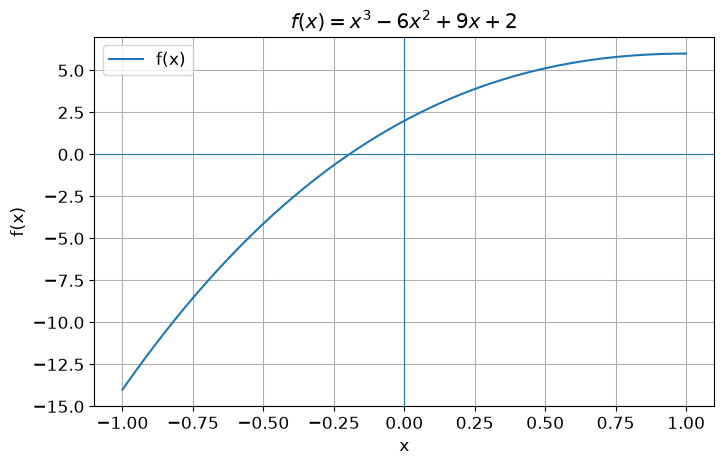

In [2]:
def f(x):
    return x**3 - 6*x**2 + 9*x + 2


def df(x):
    return 3*x**2 - 12*x + 9


x_grid = np.linspace(-1, 1, 600)

plt.figure()
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.plot(x_grid, f(x_grid), label="f(x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"$f(x)=x^3-6x^2+9x+2$")
plt.grid(True)
plt.legend()
plt.show()

## 1.1. Локализация корня

По графику определите, где функция пересекает ось $Ox$.

Для дальнейших вычислений в основной части работы используйте рабочий отрезок

$$
[a,b]=[-0.5,\,0].
$$

Перед использованием отрезка необходимо убедиться, что

$$
f(a)\,f(b)<0.
$$

Это условие гарантирует наличие хотя бы одного корня внутри отрезка для непрерывной функции.

### Задание

Запустите следующую ячейку и объясните полученный результат.

In [3]:
a, b = -0.5, 0.0

print("f(a) =", f(a))
print("f(b) =", f(b))
print("f(a) * f(b) =", f(a) * f(b))

f(a) = -4.125
f(b) = 2.0
f(a) * f(b) = -8.25


# 2. Метод бисекции

## 2.1. Идея метода

Пусть функция непрерывна на $[a,b]$ и

$$
f(a)f(b)<0.
$$

Тогда внутри отрезка существует хотя бы один корень.

Алгоритм:

1. найти середину

$$
c=\frac{a+b}{2};
$$

2. определить, в какой половине сохраняется смена знака;
3. отбросить вторую половину;
4. повторять процесс.

На каждом шаге длина рабочего отрезка уменьшается вдвое.

### Критерий остановки

Для бисекции естественным критерием является малый размер отрезка:

$$
\frac{|b-a|}{2}<\varepsilon.
$$

Дополнительно можно остановиться, если уже выполнено

$$
|f(c)|<\varepsilon.
$$

### Что должна делать ваша функция

`bisection(f, a, b, eps, max_iter)` должна:

- проверять `a < b`;
- проверять смену знака на концах;
- последовательно делить отрезок пополам;
- сохранять каждое приближение `c` в `history`;
- завершать работу по критерию точности;
- выдавать понятную ошибку, если условия метода нарушены;
- выдавать ошибку, если достигнут `max_iter`.

Функция должна возвращать:

```python
(root, history)
```

где `len(history)` соответствует числу выполненных итераций.

In [4]:
def bisection(f, a, b, eps=1e-8, max_iter=1000):
    # TODO:
    # 1. Проверить корректность a, b, eps и max_iter
    # 2. Проверить условие f(a) * f(b) < 0
    # 3. Реализовать цикл деления отрезка пополам
    # 4. Сохранять каждое значение c в history
    # 5. Реализовать критерий остановки
    # 6. Обработать исчерпание max_iter
    if eps < 0:
        raise ValueError("Точность не может быть отрицательной")
    if not (0 < max_iter < 10 ** 4):
        raise ValueError("Максимальное количество итераций не удовлетворяет эффективным ограничениям")
    if a > b:
        raise ValueError("Верхняя граница отрезка должна быть больше нижней")
    if a == b:
        raise ValueError("Указан отрезок нулевой длины")
    if f(a) * f(b) >= 0:
        raise ValueError("Функция на заданном отрезке должна менять свой знак")

    history, c = [], None
    while not (abs(b - a) / 2 < eps):
        if max_iter <= 0:
            raise RuntimeError("Был исчерпан лимит итераций")
        
        if f(a) * f(b) < 0:
            c = (a + b) / 2

            if f(a) * f(c) < 0:
                b = c
            elif f(c) * f(b) < 0:
                a = c

            history.append(c)
            max_iter -= 1

            if f(c) == 0:
               break

    return (c, history)
        
    

In [5]:
try:
    root_bis, hist_bis = bisection(f, a, b, eps=1e-8)
    print(f"Корень: {root_bis:.12f}")
    print(f"Итераций: {len(hist_bis)}")
    print(f"Невязка: {abs(f(root_bis)):.3e}")
except NotImplementedError:
    print("Сначала реализуйте функцию bisection().")

Корень: -0.195823356509
Итераций: 25
Невязка: 1.268e-07


# 3. Метод Ньютона

## 3.1. Итерационная формула

Метод Ньютона использует производную функции:

$$
x_{n+1}=x_n-\frac{f(x_n)}{f'(x_n)}.
$$

Геометрически в точке $x_n$ проводится касательная к графику функции, а её пересечение
с осью $Ox$ используется как следующее приближение.

Вблизи простого корня и при удачном выборе $x_0$ метод обычно сходится значительно быстрее
бисекции.

## 3.2. Почему нужна проверка производной?

Если

$$
|f'(x_n)|\approx 0,
$$

в формуле Ньютона возникает деление на очень малое число. Следующий шаг может стать
чрезмерно большим или вообще неопределённым.

Поэтому реализация должна содержать защиту от почти нулевой производной.

## 3.3. Критерий остановки

В этой работе рекомендуется проверять **два признака одновременно**:

$$
|x_{n+1}-x_n|<\varepsilon
$$

и

$$
|f(x_{n+1})|<\varepsilon.
$$

Первая величина показывает стабилизацию последовательности, вторая — выполнение исходного
уравнения.

### Что должна делать `newton`

- принимать `f`, `df`, начальное приближение `x0`;
- выполнять шаги Ньютона;
- проверять производную перед делением;
- проверять конечность вычисленных значений;
- сохранять новые приближения в `history`;
- останавливаться только после выполнения выбранного критерия;
- обрабатывать `max_iter`.

!) Может дать сбой

In [6]:
def newton(f, df, x0, eps=1e-8, max_iter=1000):
    # TODO:
    # 1. Проверить eps и max_iter
    # 2. На каждом шаге вычислить f(x) и df(x)
    # 3. Защититься от почти нулевой производной
    # 4. Выполнить шаг Ньютона
    # 5. Добавить новое приближение в history
    # 6. Проверить одновременно шаг и невязку
    # 7. Обработать max_iter
    if eps < 0:
        raise ValueError("Точность не может быть отрицательной")
    if not (0 < max_iter < 10 ** 4):
        raise ValueError("Максимальное количество итераций не удовлетворяет эффективным ограничениям")

    history = []
    xn = x0

    if abs(df(xn)) > 1e-12:
        xn1 = xn - f(xn)/df(xn)
    else:
        raise ValueError("Сработала защита от слишком малой производной")
    history.append(xn1)
    while not (abs(xn1 - xn) < eps and abs(f(xn1)) < eps):
        if abs(df(xn)) < 1e-12:
           raise ValueError("Сработала защита от слишком малой производной")

        if max_iter <= 0:
            raise RuntimeError("Превышено максимальное количество итераций")
            
        xn = xn1
        xn1 = xn - f(xn)/df(xn)
        history.append(xn1)

        max_iter -= 1
    return xn1, history


In [7]:
x0 = -0.25

try:
    root_newton, hist_newton = newton(f, df, x0, eps=1e-8)
    print(f"Начальное приближение: {x0}")
    print(f"Корень: {root_newton:.12f}")
    print(f"Итераций: {len(hist_newton)}")
    print(f"Невязка: {abs(f(root_newton)):.3e}")
except NotImplementedError:
    print("Сначала реализуйте функцию newton().")

Начальное приближение: -0.25
Корень: -0.195823345446
Итераций: 4
Невязка: 2.220e-16


# 4. Метод простой итерации

## 4.1. Переход от $f(x)=0$ к $x=\varphi(x)$

Уравнение представляется в виде

$$
x=\varphi(x).
$$

В этой работе используем преобразование

$$
\varphi(x)=x-\lambda f(x).
$$

Итерационный процесс:

$$
x_{n+1}=\varphi(x_n).
$$

Но произвольное значение $\lambda$ выбирать нельзя.

## 4.2. Условие сжимающего отображения

Достаточное условие сходимости на рабочем отрезке:

$$
|\varphi'(x)|\le q<1.
$$

Так как

$$
\varphi'(x)=1-\lambda f'(x),
$$

необходимо подобрать $\lambda$, чтобы модуль этой производной был меньше единицы
на всём рабочем отрезке.

Для дальнейшего исследования простой итерации используйте

$$
[a,b]=[-0.5,0].
$$

Если на этом отрезке

$$
0<m\le f'(x)\le M,
$$

то удобный выбор

$$
\lambda=\frac{2}{m+M}.
$$

После выбора $\lambda$ необходимо **проверить**, что

$$
q=\max_{x\in[a,b]}|1-\lambda f'(x)|<1.
$$

Кроме того, для применения теоремы о сжатии следует убедиться, что итерации остаются
на рабочем отрезке.

### Задание 4.1

Определите `m`, `M`, выберите `lam` и вычислите `q`.

Числа `m` и `M` можно найти аналитически либо оценить по достаточно плотной сетке. (границы около корня, f'(a) = m, f'(b) = M)

In [8]:
# TODO: определить m и M для df(x) на [a, b]
a = -0.5
b = 0.0

m = min(df(b), df(a))
M = max(df(a), df(b))

# TODO: подобрать lam
lam = 2  / (m + M)

phi = lambda x: x - lam * f(x)
dphi = lambda x: 1 - lam * df(x)

# TODO: оценить q = max |phi'(x)| на [a, b]
q = np.max(np.abs(dphi(np.linspace(a, b, 1000))))

print("m =", m)
print("M =", M)
print("lambda =", lam)
print("q =", q)

m = 9.0
M = 15.75
lambda = 0.08080808080808081
q = 0.27272727272727293


## 4.3. Реализация простой итерации

Функция `fixed_point(phi, x0, eps, max_iter)` должна:

- вычислять $x_{n+1}=\varphi(x_n)$;
- сохранять новые приближения в `history`;
- проверять конечность значений;
- использовать критерий по шагу **и** невязке исходного уравнения;
- завершать работу по `max_iter`, если сходимость не достигнута.

Поскольку функция `fixed_point` получает только `phi`, невязку $f(x)$ можно либо передать
отдельным аргументом, либо использовать внешнюю функцию `f` для данной лабораторной.

В этой заготовке используйте второй вариант, чтобы сохранить исходную сигнатуру функции.

In [9]:
def fixed_point(phi, x0, eps=1e-8, max_iter=1000):
    # TODO:
    # 1. Реализовать итерационный процесс x_new = phi(x)
    # 2. Проверить конечность вычислений
    # 3. Сохранять историю
    # 4. Использовать критерий по шагу и невязке |f(x_new)|
    # 5. Обработать отсутствие сходимости за max_iter
    if eps < 0:
        raise ValueError("Точность не может быть отрицательной")
    if not (0 < max_iter < 10 ** 4):
        raise ValueError("Максимальное количество итераций не удовлетворяет эффективным ограничениям")
    
    history = []
    x = phi(x0)
    while not(abs(f(x)) < eps and abs(x - x0) < eps):
        if max_iter <= 0:
            raise RuntimeError("Превышен лимит итераций")
        if not np.isfinite(x):
            raise RuntimeError("Получено неконечное значение")
            
        history.append(x)
        x0 = x
        x = phi(x)

        max_iter -= 1
    
    return x, history + [x]

In [10]:
x0_fp = -0.25

try:
    if lam is ...:
        print("Сначала подберите lambda.")
    else:
        root_fp, hist_fp = fixed_point(phi, x0_fp, eps=1e-8)
        print(f"q = {q:.6f}")
        print(f"Корень: {root_fp:.12f}")
        print(f"Итераций: {len(hist_fp)}")
        print(f"Невязка: {abs(f(root_fp)):.3e}")
except NotImplementedError:
    print("Сначала реализуйте fixed_point().")

q = 0.272727
Корень: -0.195823345820
Итераций: 7
Невязка: 4.287e-09


# 5. Сравнение методов

Теперь методы необходимо сравнить **в одинаковых условиях**.

Для

$$
\varepsilon=10^{-3},\;10^{-6},\;10^{-9}
$$

для каждого метода определите:

- найденный корень;
- число итераций;
- невязку $ |f(x^*)| $;
- абсолютное отличие от эталонного решения.

В качестве эталонной библиотечной реализации используйте

```python
scipy.optimize.brentq
```

Библиотечный результат не заменяет собственную реализацию, а используется для независимой
проверки.

In [11]:
reference = brentq(f, a, b)
eps_values = [1e-3, 1e-6, 1e-9]

results = []

# TODO:
# Для каждого eps:
# 1. запустить bisection
# 2. запустить newton
# 3. запустить fixed_point
# 4. сохранить:
#    method, eps, root, iterations, residual, abs_error
#
# Рекомендуемые начальные данные:
# bisection: [a, b]
# Newton: x0 = -0.25
# fixed point: x0 = -0.25
x0 = -0.25
for eps in eps_values:
    root, history = bisection(f, a, b, eps=eps)
    results.append({"method": "bisection", "eps": eps, "root": root, "iterations": len(history), 
                       "residual": abs(f(root)), "abs_error": abs(reference - root)})

    root, history = newton(f, df, x0, eps=eps)
    results.append({"method": "newton", "eps": eps, "root": root, "iterations": len(history), 
                       "residual": abs(f(root)), "abs_error": abs(reference - root)})

    root, history = fixed_point(phi, x0_fp, eps=eps)
    results.append({"method": "fixed_point", "eps": eps, "root": root, "iterations": len(history), 
                       "residual": abs(f(root)), "abs_error": abs(reference - root)})


print("Эталонный корень:", reference)
results

Эталонный корень: -0.19582334544564728


[{'method': 'bisection',
  'eps': 0.001,
  'root': -0.197265625,
  'iterations': 8,
  'residual': 0.016549326479434967,
  'abs_error': 0.0014422795543527211},
 {'method': 'newton',
  'eps': 0.001,
  'root': -0.19582334544692628,
  'iterations': 3,
  'residual': 1.4665157976878618e-11,
  'abs_error': 1.279004679943796e-12},
 {'method': 'fixed_point',
  'eps': 0.001,
  'root': -0.19583613074996278,
  'iterations': 3,
  'residual': 0.00014658357427643764,
  'abs_error': 1.278530431550462e-05},
 {'method': 'bisection',
  'eps': 1e-06,
  'root': -0.19582176208496094,
  'iterations': 18,
  'residual': 1.8153087864458683e-05,
  'abs_error': 1.5833606863413507e-06},
 {'method': 'newton',
  'eps': 1e-06,
  'root': -0.19582334544564714,
  'iterations': 4,
  'residual': 2.220446049250313e-16,
  'abs_error': 1.3877787807814457e-16},
 {'method': 'fixed_point',
  'eps': 1e-06,
  'root': -0.19582341458672978,
  'iterations': 5,
  'residual': 7.926970466698435e-07,
  'abs_error': 6.914108249822526e-08

# 6. График сходимости

Для одного достаточно строгого значения точности, например

$$
\varepsilon=10^{-12},
$$

постройте на одной координатной плоскости зависимость

$$
\log_{10}|f(x_n)|
$$

от номера итерации для всех трёх методов.

### Что должно быть на графике

- подпись оси $x$;
- подпись оси $y$;
- заголовок;
- сетка;
- легенда;
- различимые кривые.

По графику необходимо сделать вывод о практической скорости сходимости методов.

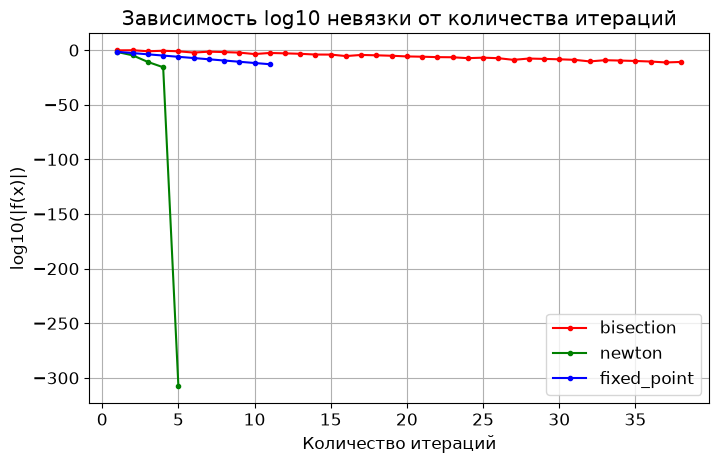

In [12]:
# TODO:
# 1. Запустить три метода с eps = 1e-12
# 2. По каждому history вычислить |f(x_n)|
# 3. Построить log10 невязки от номера итерации
# 4. Не забыть обработать случай нулевой невязки перед log10
eps = 1e-12

def plot_residual(history, line, label, marker_size=3):
    res = np.abs(f(np.array(history)))
    res = np.where(res == 0, np.finfo(float).tiny, res)
    plt.plot(np.arange(1, len(res) + 1), np.log10(res), line, label=label, markersize=marker_size)

plot_residual(bisection(f, a, b, eps=eps)[1], 'r-o', 'bisection')
plot_residual(newton(f, df, x0, eps=eps)[1], 'g-o', 'newton')
plot_residual(fixed_point(phi, x0_fp, eps=eps)[1], 'b-o', 'fixed_point')

plt.grid(True)
plt.legend()
plt.title("Зависимость log10 невязки от количества итераций")
plt.xlabel("Количество итераций")
plt.ylabel("log10(|f(x)|)")

plt.show()

***Вывод по графику***: наивысшую практическую скорость сходимости показывает метод Ньютона, за ним идет метод простой итерации, а бисекция является самой медленной, но при этом метод Ньютона чувствителен к выбору начальной точки и уходит в защиту при малых значениях производной


# 7. Влияние начального приближения на метод Ньютона

Метод Ньютона чувствителен к выбору $x_0$.

Проверьте несколько начальных приближений, например:

```python
[-0.5, 0.0, 0.5, 0.9, 1.0, 1.5, 2.0]
```

Для каждого случая зафиксируйте:

- сошёлся ли метод;
- найденный корень;
- число итераций;
- возникла ли ошибка из-за малой производной.

Особое внимание уделите $x_0=1$.

Не требуется искусственно отключать защиту от малой производной: корректная обработка
такой ситуации и является частью задания.



In [13]:
x0_values = [-0.5, 0.0, 0.5, 0.9, 1.0, 1.5, 2.0]

# TODO:
# Для каждого x0 запустить newton() внутри try/except
# и вывести результат или тип возникшей ошибки.
for x0 in x0_values:
    try:
        root, history = newton(f, df, x0, eps=1e-8)
        print(root, len(history), abs(f(root)), sep='\t')
    except Exception as e:
        print(f"Ошибка {e}")

-0.19582334544564717	5	0.0
-0.19582334544564714	5	2.220446049250313e-16
-0.1958233454456472	6	4.440892098500626e-16
-0.19582334544564714	10	2.220446049250313e-16
Ошибка Сработала защита от слишком малой производной
-0.19582334544564714	21	2.220446049250313e-16
-0.19582334544564717	44	0.0


## 7.1. Дополнительное исследование: практический порядок Ньютона

Вблизи простого корня метод Ньютона обладает квадратичной сходимостью.

По последовательности невязок $r_n=|f(x_n)|$ практический порядок можно приблизительно
оценивать выражением

$$
p_n \approx
\frac{\ln(r_{n+1}/r_n)}
{\ln(r_n/r_{n-1})}.
$$

Значения в самых первых итерациях могут ещё не отражать асимптотический режим, а в самых
последних на результат уже способно влиять машинное округление.

In [14]:
# ДОПОЛНИТЕЛЬНО:
# Используйте историю метода Ньютона при строгой eps
# и оцените p_n по трём последовательным невязкам.
eps, x0 = 1e-12, -0.25

root, history = newton(f, df, x0, eps=eps)
residuals = np.abs(f(np.array(history)))
i = 1
p_n = np.log(residuals[i + 1] / residuals[i]) / np.log(residuals[i] / residuals[i - 1])
print(p_n)

1.9995396593745396


# 8. Анализ результатов

В отчёте необходимо не просто перечислить найденные числа, а объяснить наблюдаемое поведение.

Ответьте по результатам **своих вычислений**.

### 8.1. Бисекция

Почему метод бисекции является надёжным при выполнении условия смены знака?  
Как изменение $\varepsilon$ влияет на число итераций?

**Ответ:** Метод бисекции не зависит от начального приближения, а при условии непрерывности функции на отрезке выполняется условия 1-ой теоремы Больцано-Коши,
что гарантирует появление на этом отрезке корня. Изменение $\varepsilon$ напрямую влияет на количество итераций, а именно при уменьшении $\varepsilon$ возрастает количество итераций.

### 8.2. Метод Ньютона

Почему метод Ньютона оказался быстрее или медленнее других методов?  
Как повлиял выбор начального приближения?

**Ответ:** Вблизи простого корня метод Ньютона обладает квадратичной сходимостью: число верных знаков примерно удваивается на каждой итерации. Выбор начального значения сильно влияет на работу алгоритма: при удачном начальном приближении алгоритм за рекордное количество итераций выходит на высокую точность, в то время как при менее удачных значениях достигает такой же  точности за почти в 4-8 раз больше итераций, помимо этого при x0=1 (корень производной) срабатывает защита от деления на около нулевую производную.

### 8.3. Простая итерация

Как было выбрано $\lambda$?  
Какое значение $q$ получено и что оно означает?

**Ответ:** Значение $\lambda$ было получено путем вычисления значения производной функции $f$ на краях отрезка и подстановки этих значений в формулу 2 / (m + M). Значение $q$ составляет 0.272727, что означает, во-первых, выполнение условия сжимающего отображения, а во-вторых, линейность сходимости данного метода.

### 8.4. Сравнение

Какой метод оказался наиболее быстрым?  
Какой метод имеет наиболее очевидные гарантии сходимости?  
Можно ли выбирать метод только по числу итераций?

**Ответ:** Наиболее быстрым по числу итераций оказался метод Ньютона. Это объясняется квадратичной сходимостью вблизи простого корня.

Наиболее очевидные гарантии сходимости имеет метод бисекции: при непрерывности функции и выполнении условия f(a)f(b)<0 он обязательно сходится, хотя и медленнее остальных.

Выбирать метод только по числу итераций нельзя. Нужно учитывать:
 - условия применимости метода;
 - необходимость производной (и проверка не будет ли она стремиться к нулю на выбранном отрезке);
 - чувствительность к начальному приближению;
 - гарантии сходимости;

# 9. Требования к представлению результатов и оформлению отчёта

Отчёт оформляется в **PDF**.

Рекомендуемая структура:

1. **Титульный лист**.
2. **Цель работы**.
3. **Краткая теоретическая часть** — основные формулы и условия применимости методов;
   ориентировочно не более 1–1.5 страниц.
4. **Описание программной реализации** — структура решения, использованные библиотеки,
   ключевые фрагменты алгоритмов.
5. **Результаты вычислительных экспериментов**:
   - исходные данные;
   - таблица сравнения методов;
   - найденные корни;
   - число итераций;
   - невязки;
   - сравнение с эталонной реализацией;
   - график сходимости;
   - исследование метода Ньютона при разных $x_0$.
6. **Выводы** — аналитические заключения по полученным данным.
7. При необходимости — **приложение** с полным листингом.

## Требования к графикам

Каждый график должен иметь:

- заголовок;
- подписи осей;
- единицы измерения, если величины размерные;
- сетку;
- легенду, если показано несколько кривых;
- читаемый масштаб.

Для невязок, меняющихся на много порядков, используйте логарифмическое представление.

## Требования к таблицам и числам

- у таблицы должно быть понятное название;
- однотипные величины оформляются с одинаковой разумной точностью;
- не следует выводить бессмысленное количество знаков после запятой;
- каждую таблицу и рисунок необходимо прокомментировать в тексте;
- в выводах следует анализировать результаты, а не пересказывать теоретическую часть.

## Воспроизводимость

Перед сдачей перезапустите ядро и выполните все ячейки **сверху вниз**. Блокнот должен
выполняться без ручного изменения переменных в произвольном порядке.

# 10. Из чего складывается оценка

### Шкала

- **5** — работа выполнена полно, материал усвоен уверенно;
- **4** — работа выполнена полно, основной материал усвоен, возможны отдельные негрубые ошибки;
- **3** — основная часть выполнена, но имеются пробелы в понимании или анализе;
- **2** — работа выполнена не полностью либо отсутствует минимальное понимание метода и собственной реализации.

> Использование справочных материалов и нейросетей само по себе не заменяет защиту:
> студент должен уметь объяснить использованный алгоритм, критерии остановки, проверки
> корректности и полученные графики.

# 11. Возможные вопросы на защите

Преподаватель выбирает несколько вопросов из списка и может попросить показать ответ
непосредственно на вашем коде или графике.

## Базовые вопросы

1. Что называется корнем нелинейного уравнения?
2. Что показывает невязка $ |f(x^*)| $?
3. Какое условие необходимо проверить перед запуском бисекции?
4. Почему бисекция гарантированно сужает область поиска корня?
5. Как записывается итерационная формула метода Ньютона?
6. Почему метод Ньютона чувствителен к выбору начального приближения?
7. Что происходит, если $f'(x_n)$ близка к нулю?
8. Что означает условие $ |\varphi'(x)|<1 $ для простой итерации?
9. Как связан параметр $\lambda$ с функцией $\varphi(x)=x-\lambda f(x)$?
10. Как отличаются скорости сходимости бисекции, Ньютона и простой итерации?

## Вопросы по вашей реализации и эксперименту

11. Какой именно критерий остановки реализован в каждом методе?
12. Почему малая величина $ |x_{n+1}-x_n| $ сама по себе ещё не всегда гарантирует малую невязку?
13. Как вы проверили, что выбранное `lam` действительно делает `phi` сжимающим отображением?
14. Какое максимальное значение $ |\varphi'(x)| $ вы получили?
15. Что делает ваша программа, если производная в методе Ньютона почти равна нулю?
16. По графику невязок объясните, какой метод практически сходится быстрее.
17. Почему на самых первых или последних шагах график может не отражать теоретический порядок сходимости?
18. Что произойдёт, если передать бисекции интервал, на концах которого функция имеет одинаковый знак?
19. Означает ли одинаковый знак функции на концах, что внутри отрезка корней точно нет?
20. Чем собственная реализация отличается от использования `scipy.optimize.brentq`?

## Возможные небольшие изменения кода на защите

Преподаватель может попросить:

- изменить `eps` и заранее предположить, как изменится число итераций;
- заменить начальное приближение Ньютона;
- показать обработку $x_0=1$;
- передать бисекции некорректный интервал;
- вывести невязку на каждой итерации;
- изменить критерий остановки и объяснить последствия;
- построить график только для двух выбранных методов;
- проверить сходимость простой итерации для другого `lam`.